In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2025-05-14 11:40:47.980177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747222848.244382      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747222848.330402      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# --- Step 1: Load Data and Initial Cleaning (adapted from notebook) ---
# Adjust path if necessary based on your environment
file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx' # This path is from the notebook.
# In a local environment, you'd replace this with the actual path to your file.
# For this example, since I cannot directly access the file, I will create a placeholder DataFrame.
# If you run this code, replace the placeholder with your actual data loading.
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully from a Kaggle environment or if the file is accessible.")
    if 'SUBJECT_ID' in df.columns:
        df.drop('SUBJECT_ID', axis=1, inplace=True)
except FileNotFoundError:
    print(f"File not found at {file_path}. Using placeholder data for demonstration.")
    # Create a sample DataFrame with similar characteristics if the file isn't found
    # This is just for the code to run without the actual file.
    # Replace this with your actual data when you run the script.
    rng = np.random.default_rng(42)
    n_samples = 500
    hematological_features_placeholder = ['BASO#', 'BASO%', 'EO#', 'EO%', 'HCT', 'HGB', 'LYM#', 'LYM%', 'MCH', 'MCV', 'MONO#', 'MONO%', 'MPV', 'NEU', 'PCT', 'PDW', 'PLT', 'RBC', 'RDW']
    clinical_features_placeholder = ['AG', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BUN', 'Ca', 'CL', 'CO2CP', 'CREA', 'DBIL', 'GGT', 'GLO', 'GLU.', 'IBIL', 'K', 'Menopause', 'Mg', 'Na', 'PHOS', 'TBIL', 'TP', 'UA']
    all_features_placeholder = hematological_features_placeholder + clinical_features_placeholder
    data_placeholder = {col: rng.random(n_samples) * 100 for col in all_features_placeholder}

    # Add some NaNs to simulate real data
    for col in data_placeholder:
        if rng.random() < 0.1: # ~10% chance to add NaNs
             nan_indices = rng.choice(n_samples, size=int(n_samples * 0.05), replace=False)
             data_placeholder[col][nan_indices] = np.nan

    data_placeholder['TYPE'] = rng.integers(0, 2, n_samples) # Target variable (0 or 1)
    df = pd.DataFrame(data_placeholder)


# Define the clinical and hematological feature names (from notebook)
hematological_features = ['BASO#', 'BASO%', 'EO#', 'EO%', 'HCT', 'HGB', 'LYM#', 'LYM%', 'MCH', 'MCV', 'MONO#', 'MONO%', 'MPV', 'NEU', 'PCT', 'PDW', 'PLT', 'RBC', 'RDW']
clinical_features = ['AG', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BUN', 'Ca', 'CL', 'CO2CP', 'CREA', 'DBIL', 'GGT', 'GLO', 'GLU.', 'IBIL', 'K', 'Menopause', 'Mg', 'Na', 'PHOS', 'TBIL', 'TP', 'UA']
clin_hem_features = hematological_features + clinical_features

# Ensure all defined features are present in the DataFrame, add them with NaNs if not
for feature in clin_hem_features:
    if feature not in df.columns:
        print(f"Feature '{feature}' not found in DataFrame, adding it as a column of NaNs.")
        df[feature] = np.nan
if 'TYPE' not in df.columns: # Ensure target column is present
    print(f"Target column 'TYPE' not found in DataFrame, adding it as a column of random 0s and 1s.")
    df['TYPE'] = np.random.randint(0, 2, size=len(df))


# Check for object columns and clean them (from notebook)
object_columns_in_set = df[clin_hem_features].select_dtypes(include=['object']).columns.tolist()

def clean_numeric_columns(df_in, columns):
    df_out = df_in.copy()
    def clean_value(x):
        if pd.isna(x): return np.nan
        if isinstance(x, (int, float)): return float(x)
        if isinstance(x, str):
            cleaned = re.sub(r'\\t|\s+', '', x) # Corrected regex from \\\\t to \\t
            try: return float(cleaned)
            except ValueError: return np.nan
        return np.nan
    for col in columns:
        if col in df_out.columns: # Check if column exists before trying to clean
             df_out[col] = df_out[col].apply(clean_value).astype(float)
    return df_out

if object_columns_in_set:
    print(f"Object columns to clean in clin/hem set: {object_columns_in_set}")
    df = clean_numeric_columns(df, object_columns_in_set)
    print("Numeric columns cleaned.")
else:
    print("No object-type columns found in the selected clinical/hematological features that need cleaning based on type.")


Data loaded successfully from a Kaggle environment or if the file is accessible.
No object-type columns found in the selected clinical/hematological features that need cleaning based on type.


In [3]:
# --- Step 2: Impute Missing Values (adapted from notebook) ---
BIOMARKER_DISTRIBUTIONS = {
   'AFP': {'mean': 5, 'std': 2.5, 'units': 'ng/mL'},
   'CA125': {'mean': 17, 'std': 9, 'units': 'U/mL' },
   'CA19-9': {'mean': 18, 'std': 9.5, 'units': 'U/mL' },
   'CA72-4': {'mean': 3.5, 'std': 1.7, 'units': 'U/mL' },
   'HE4': {'mean': 70, 'std': 20, 'units': 'pmol/L'},
   'AG': {'mean': 12, 'std': 2, 'units': 'mEq/L'},
   'ALB': {'mean': 4.4, 'std': 0.5, 'units': 'g/dL'},
   'ALP': {'mean': 80, 'std': 30, 'units': 'IU/L'},
   'ALT': {'mean': 30, 'std': 12, 'units': 'IU/L'},
   'AST': {'mean': 28, 'std': 10, 'units': 'IU/L' },
   'CO2CP': {'mean': 26, 'std': 1.5, 'units': 'mEq/L'},
   'DBIL': {'mean': 0.15, 'std': 0.1, 'units': 'mg/dL'},
   'GGT': {'mean': 15, 'std': 7, 'units': 'U/L'},
   'GLO': {'mean': 2.9, 'std': 0.3, 'units': 'g/dL' },
   'IBIL': { 'mean': 0.5, 'std': 0.2,  'units': 'mg/dL'},
   'MPV': { 'mean': 9.5, 'std': 1, 'units': 'fL'},
   'NEU': {'mean': 4.75, 'std': 1.5, 'units': '10^3/μL'},
   'PCT': {'mean': 0.1, 'std': 0.2, 'units': 'ng/mL'}, # Adjusted from 0.1, 0.2
   'PDW': {'mean': 13, 'std': 2, 'units': '%'},
   'TBIL': {'mean': 0.75, 'std': 0.3,  'units': 'mg/dL' },
   'TP': { 'mean': 7.15,  'std': 0.5,  'units': 'g/dL' }
}

def generate_biomarker_imputation(df_in, biomarkers=None, seed=42):
    imputed_df_out = df_in.copy()
    np.random.seed(seed)
    if biomarkers is None:
        biomarkers = list(BIOMARKER_DISTRIBUTIONS.keys())
    imputation_details_out = {}
    for marker in biomarkers:
        if marker not in imputed_df_out.columns or not imputed_df_out[marker].isna().any():
            continue
        dist_params = BIOMARKER_DISTRIBUTIONS.get(marker) # Use .get() for safety
        if not dist_params:
            print(f"Warning: No distribution params for marker {marker}, skipping normal imputation.")
            continue
        missing_mask = imputed_df_out[marker].isna()
        n_missing = missing_mask.sum()
        impute_values = np.random.normal(
            loc=dist_params['mean'], scale=dist_params['std'], size=n_missing
        )
        impute_values[impute_values < 0] = 0 # Ensure non-negative
        imputed_df_out.loc[missing_mask, marker] = impute_values
        imputation_details_out[marker] = {'n_imputed': n_missing, 'imputation_mean': dist_params['mean'], 'imputation_std': dist_params['std'], 'units': dist_params['units']}
    return imputed_df_out, imputation_details_out

# Impute missing values for clinical/hematological features
df_imputed = df.copy() # Start with the original or placeholder df
features_to_impute_dist = [f for f in clin_hem_features if f in df_imputed.columns and df_imputed[f].isnull().any() and f in BIOMARKER_DISTRIBUTIONS]
if features_to_impute_dist:
    df_imputed, details = generate_biomarker_imputation(df_imputed, biomarkers=features_to_impute_dist)
    print("Imputation details (Normal Distribution):", details)
else:
    print("No features require imputation based on normal distribution or they are not in BIOMARKER_DISTRIBUTIONS.")


# Impute remaining NaNs in selected clinical/hematological features with their respective means
print("\nImputing remaining NaNs with column means:")
for col in clin_hem_features:
   if col in df_imputed.columns and df_imputed[col].isnull().any(): # Check if column exists
       mean_val = df_imputed[col].mean()
       if pd.isna(mean_val): # If mean is NaN (e.g., all values were NaN)
           mean_val = 0 # Default to 0 or some other sensible default
           print(f"Warning: Mean for '{col}' is NaN. Filling with 0.")
       df_imputed[col].fillna(mean_val, inplace=True)
       print(f"Filled remaining NaNs in '{col}' with mean: {mean_val:.4f}")
   elif col not in df_imputed.columns:
        print(f"Warning: Feature column '{col}' for mean imputation not found in DataFrame.")

Imputation details (Normal Distribution): {'MPV': {'n_imputed': 2, 'imputation_mean': 9.5, 'imputation_std': 1, 'units': 'fL'}, 'NEU': {'n_imputed': 91, 'imputation_mean': 4.75, 'imputation_std': 1.5, 'units': '10^3/μL'}, 'PCT': {'n_imputed': 2, 'imputation_mean': 0.1, 'imputation_std': 0.2, 'units': 'ng/mL'}, 'PDW': {'n_imputed': 2, 'imputation_mean': 13, 'imputation_std': 2, 'units': '%'}, 'AG': {'n_imputed': 1, 'imputation_mean': 12, 'imputation_std': 2, 'units': 'mEq/L'}, 'ALB': {'n_imputed': 10, 'imputation_mean': 4.4, 'imputation_std': 0.5, 'units': 'g/dL'}, 'ALP': {'n_imputed': 10, 'imputation_mean': 80, 'imputation_std': 30, 'units': 'IU/L'}, 'ALT': {'n_imputed': 10, 'imputation_mean': 30, 'imputation_std': 12, 'units': 'IU/L'}, 'AST': {'n_imputed': 10, 'imputation_mean': 28, 'imputation_std': 10, 'units': 'IU/L'}, 'CO2CP': {'n_imputed': 1, 'imputation_mean': 26, 'imputation_std': 1.5, 'units': 'mEq/L'}, 'DBIL': {'n_imputed': 10, 'imputation_mean': 0.15, 'imputation_std': 0.1, 

In [4]:
# --- Step 3: Prepare Data for Model (adapted from notebook) ---
# Ensure all clin_hem_features are actually in the df_imputed before selection
final_features_for_model = [f for f in clin_hem_features if f in df_imputed.columns]
missing_from_df = set(clin_hem_features) - set(final_features_for_model)
if missing_from_df:
    print(f"Warning: The following features were defined but not found in the dataframe for X: {missing_from_df}")

if not final_features_for_model:
    raise ValueError("No features available for model training after preprocessing.")


X_ch = df_imputed[final_features_for_model]
y_ch = df_imputed['TYPE']

print("\nClinical/Hematological Feature matrix shape:", X_ch.shape)
print("Target vector shape:", y_ch.shape)
print("Number of NaN values in X_ch before scaling:", X_ch.isnull().sum().sum())
print("Number of NaN values in y_ch:", y_ch.isnull().sum())

# Split data
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=42, stratify=y_ch
)

# Scale features
scaler_ch = MinMaxScaler()
X_train_ch_scaled = scaler_ch.fit_transform(X_train_ch)
X_test_ch_scaled = scaler_ch.transform(X_test_ch)
print("Clinical/Hematological features scaled.")


Clinical/Hematological Feature matrix shape: (349, 43)
Target vector shape: (349,)
Number of NaN values in X_ch before scaling: 0
Number of NaN values in y_ch: 0
Clinical/Hematological features scaled.


In [5]:
# --- Step 4: Define and Train Deep Learning Model ---
print("\nDefining Deep Learning model...")

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_ch_scaled.shape[1],)),
    Dropout(0.3), # Dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

print("\nTraining Deep Learning model...")
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_ch_scaled, y_train_ch,
    epochs=100, # Increased epochs, early stopping will manage
    batch_size=32,
    validation_split=0.2, # Use part of training data for validation during training
    callbacks=[early_stopping],
    verbose=1
)


Defining Deep Learning model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-14 11:41:04.866259: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           5,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Deep Learning model...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.4934 - loss: 0.7049 - val_accuracy: 0.6071 - val_loss: 0.6783
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6690 - loss: 0.6538 - val_accuracy: 0.6786 - val_loss: 0.6539
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6044 - loss: 0.6627 - val_accuracy: 0.6786 - val_loss: 0.6267
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7380 - loss: 0.6142 - val_accuracy: 0.7321 - val_loss: 0.5970
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7559 - loss: 0.5773 - val_accuracy: 0.7143 - val_loss: 0.5643
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7108 - loss: 0.5823 - val_accuracy: 0.7321 - val_loss: 0.5428
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7474 - loss: 0.5655 - val_accuracy: 0.7321 - val_loss: 0.5132
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7791 - loss: 0.5031 - val_ac

In [6]:
# --- Step 5: Evaluate Deep Learning Model ---
print("\nEvaluating Deep Learning model...")
loss, accuracy = model.evaluate(X_test_ch_scaled, y_test_ch, verbose=0)
print(f"Test Accuracy (Deep Learning): {accuracy:.4f}")
print(f"Test Loss (Deep Learning): {loss:.4f}")

y_pred_proba_dl = model.predict(X_test_ch_scaled)
y_pred_dl = (y_pred_proba_dl > 0.5).astype(int).flatten() # Convert probabilities to binary predictions

balanced_accuracy_dl = balanced_accuracy_score(y_test_ch, y_pred_dl)
cm_dl = confusion_matrix(y_test_ch, y_pred_dl)
report_dl = classification_report(y_test_ch, y_pred_dl, target_names=['Benign', 'Ovarian Cancer'], zero_division=0)

print(f"Test Balanced Accuracy (Deep Learning): {balanced_accuracy_dl:.4f}")
print("\nClassification Report (Deep Learning):\n", report_dl)
print("\nConfusion Matrix (Deep Learning):\n", cm_dl)


Evaluating Deep Learning model...
Test Accuracy (Deep Learning): 0.8429
Test Loss (Deep Learning): 0.2823
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Test Balanced Accuracy (Deep Learning): 0.8423

Classification Report (Deep Learning):
                 precision    recall  f1-score   support

        Benign       0.85      0.82      0.84        34
Ovarian Cancer       0.84      0.86      0.85        36

      accuracy                           0.84        70
     macro avg       0.84      0.84      0.84        70
  weighted avg       0.84      0.84      0.84        70


Confusion Matrix (Deep Learning):
 [[28  6]
 [ 5 31]]


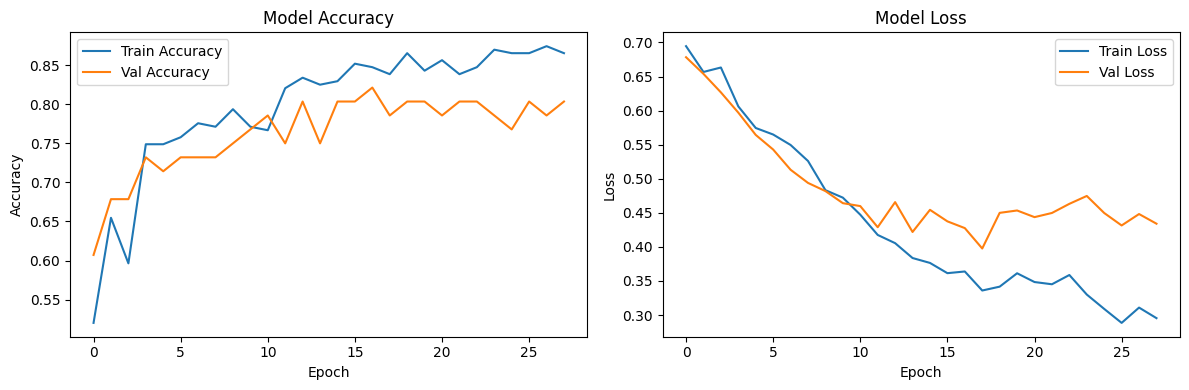


Deep Learning model script execution complete.


In [7]:
# --- Optional: Plot training history ---
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print("\nDeep Learning model script execution complete.")

Test Balanced Accuracy (Deep Learning): 0.8423


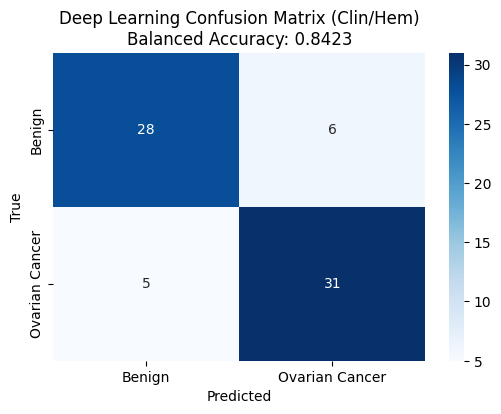

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_dl = confusion_matrix(y_test_ch, y_pred_dl)
report_dl = classification_report(y_test_ch, y_pred_dl, target_names=['Benign', 'Ovarian Cancer'], zero_division=0)

print(f"Test Balanced Accuracy (Deep Learning): {balanced_accuracy_dl:.4f}")


# --- Plot Confusion Matrix for Deep Learning Model ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Ovarian Cancer'],
            yticklabels=['Benign', 'Ovarian Cancer'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Deep Learning Confusion Matrix (Clin/Hem)\nBalanced Accuracy: {balanced_accuracy_dl:.4f}')
plt.show()